In [7]:
import pandas as pd
import numpy as np
import sklearn as sk

import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [8]:
df.shape

(7043, 21)

In [9]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [10]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000,7032.000000
mean,0.162147,32.371149,64.761692,2283.300441
std,0.368612,24.559481,30.090047,2266.771362
min,0.000000,0.000000,18.250000,18.800000
25%,0.000000,9.000000,35.500000,401.450000
50%,0.000000,29.000000,70.350000,1397.475000
75%,0.000000,55.000000,89.850000,3794.737500
max,1.000000,72.000000,118.750000,8684.800000


In [11]:
#Churn — ушёл клиент или нет
#Все остальные колонки, кроме Churn и customerID

In [12]:
df['Churn'].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

In [13]:
df['Churn'].value_counts(normalize=True) * 100

Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64

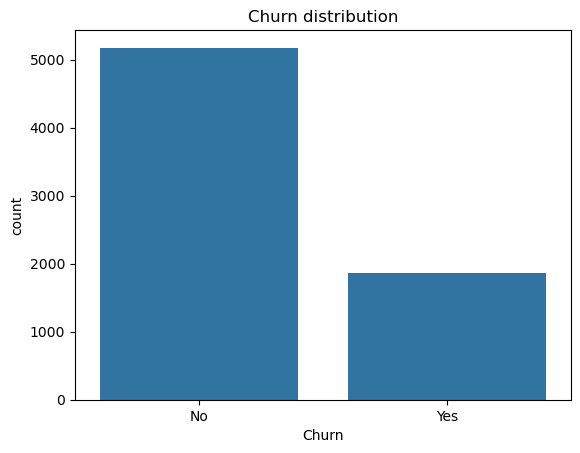

In [14]:
sns.countplot(x='Churn', data=df)
plt.title('Churn distribution')
plt.show()

In [15]:
num_features = ['tenure', 'MonthlyCharges', 'TotalCharges']

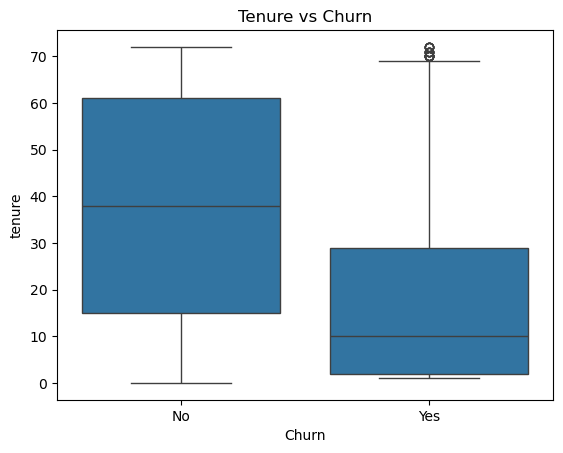

In [16]:
sns.boxplot(x='Churn', y='tenure', data=df)
plt.title('Tenure vs Churn')
plt.show()

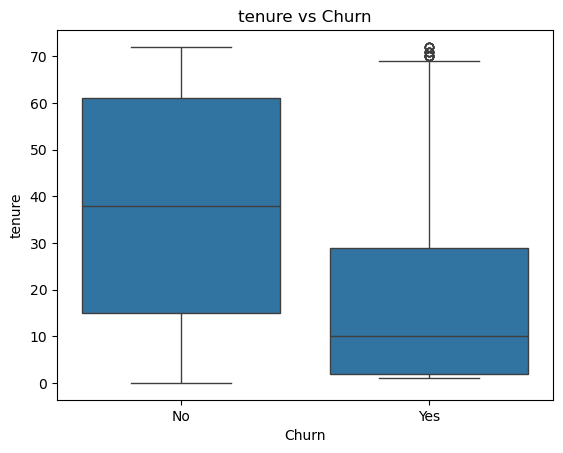

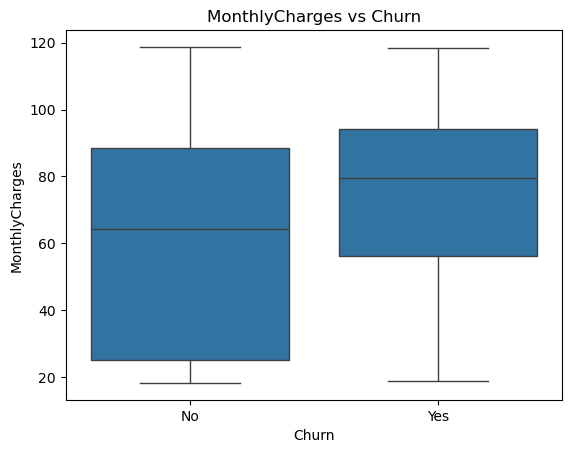

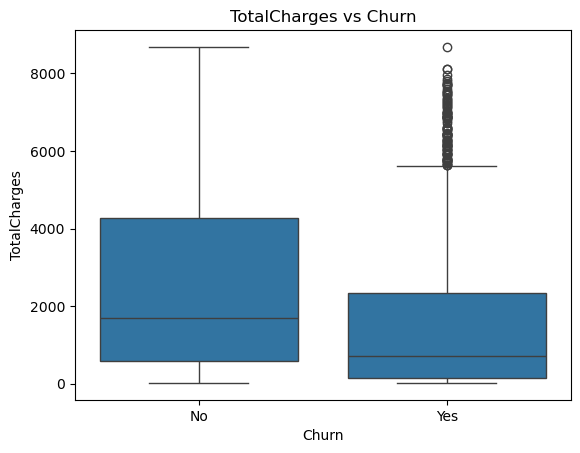

In [17]:
for col in num_features:
    sns.boxplot(x='Churn', y=col, data=df)
    plt.title(f'{col} vs Churn')
    plt.show()

In [19]:
cat_features = df.select_dtypes(include='object').columns.tolist()
cat_features.remove('Churn')
cat_features.remove('customerID')


In [20]:
contract_churn = (
    df.groupby('Contract')['Churn']
    .value_counts(normalize=True)
    .rename('share')
    .reset_index()
)

contract_churn

,Contract,Churn,share
0,Month-to-month,No,0.572903
1,Month-to-month,Yes,0.427097
2,One year,No,0.887305
3,One year,Yes,0.112695
4,Two year,No,0.971681
5,Two year,Yes,0.028319


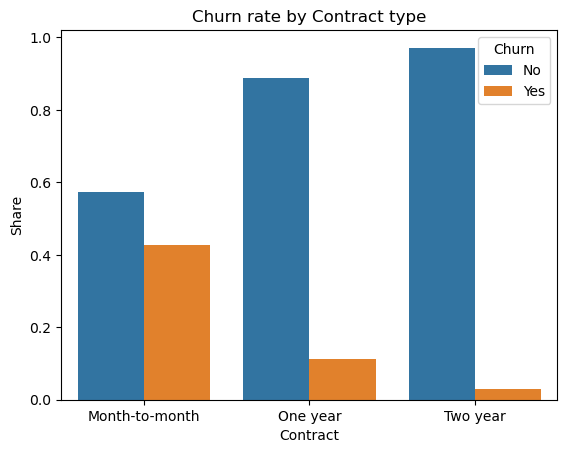

In [21]:
sns.barplot(
    data=contract_churn,
    x='Contract',
    y='share',
    hue='Churn'
)
plt.title('Churn rate by Contract type')
plt.ylabel('Share')
plt.show()

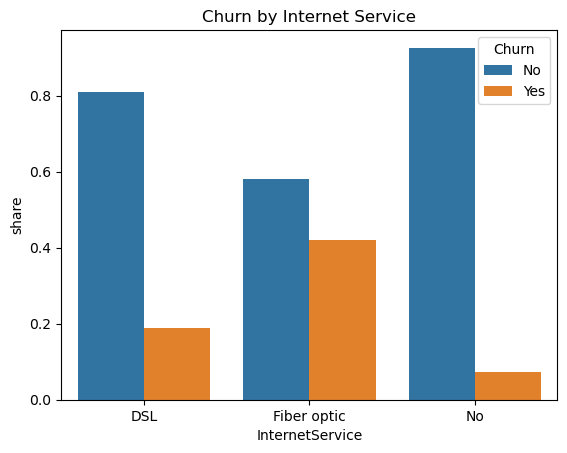

In [22]:
internet_churn = (
    df.groupby('InternetService')['Churn']
    .value_counts(normalize=True)
    .rename('share')
    .reset_index()
)

sns.barplot(
    data=internet_churn,
    x='InternetService',
    y='share',
    hue='Churn'
)
plt.title('Churn by Internet Service')
plt.show()

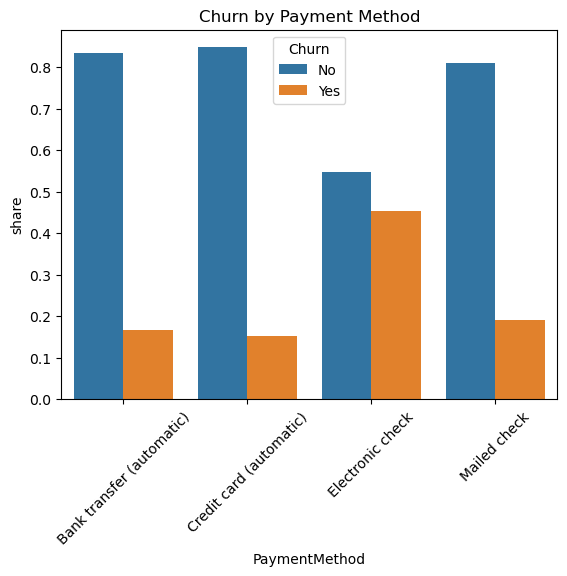

In [23]:
payment_churn = (
    df.groupby('PaymentMethod')['Churn']
    .value_counts(normalize=True)
    .rename('share')
    .reset_index()
)

sns.barplot(
    data=payment_churn,
    x='PaymentMethod',
    y='share',
    hue='Churn'
)
plt.xticks(rotation=45)
plt.title('Churn by Payment Method')
plt.show()

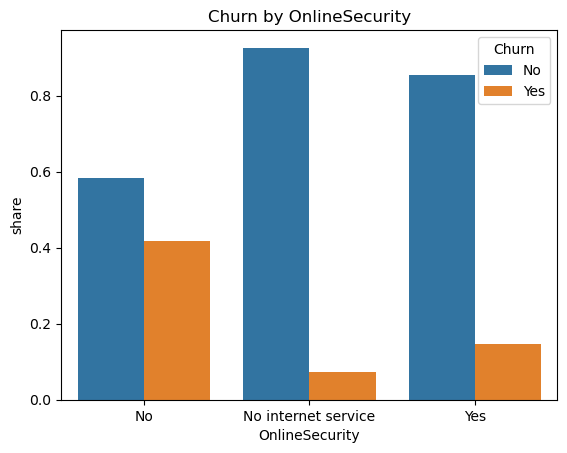

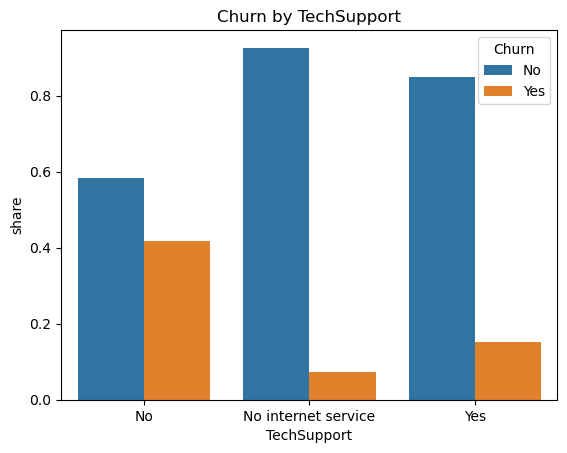

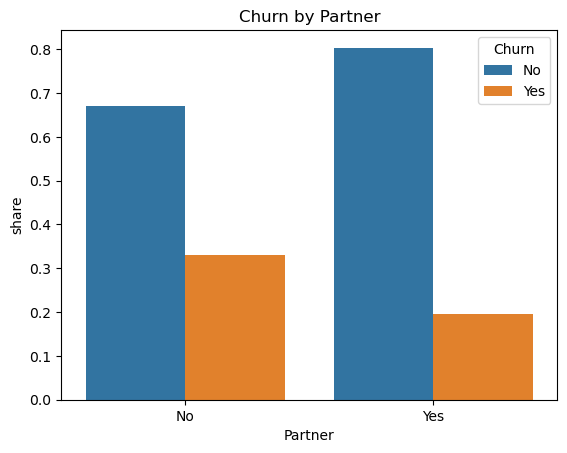

In [24]:
for col in ['OnlineSecurity', 'TechSupport', 'Partner']:
    temp = (
        df.groupby(col)['Churn']
        .value_counts(normalize=True)
        .rename('share')
        .reset_index()
    )
    
    sns.barplot(data=temp, x=col, y='share', hue='Churn')
    plt.title(f'Churn by {col}')
    plt.show()

In [25]:
df.isna().sum()

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

In [26]:
df['TotalCharges'] = df['TotalCharges'].fillna(0)

In [27]:
X = df.drop(columns=['Churn', 'customerID'])
y = df['Churn']
y = y.map({'Yes': 1, 'No': 0})


In [28]:
num_features = X.select_dtypes(include=['int64', 'float64']).columns
cat_features = X.select_dtypes(include='object').columns

In [29]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [30]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', 'passthrough', num_features),
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), cat_features)
    ]
)

In [31]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [37]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter=1000))
])

In [39]:
from sklearn.preprocessing import StandardScaler
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_features),
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), cat_features)
    ]
)

In [40]:
model.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [41]:
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

In [42]:
from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix, classification_report

In [43]:
accuracy_score(y_test, y_pred)

0.8069552874378992

In [44]:
roc_auc_score(y_test, y_proba)

0.8421710713270816

In [45]:
confusion_matrix(y_test, y_pred)

array([[927, 108],
       [164, 210]])

In [46]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.85      0.90      0.87      1035
           1       0.66      0.56      0.61       374

    accuracy                           0.81      1409
   macro avg       0.76      0.73      0.74      1409
weighted avg       0.80      0.81      0.80      1409



In [47]:
from sklearn.ensemble import RandomForestClassifier
model_rf = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(random_state=42))
])

In [48]:
model_rf.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [49]:
y_pred_rf = model_rf.predict(X_test)
y_proba_rf = model_rf.predict_proba(X_test)[:, 1]

In [50]:
roc_auc_score(y_test, y_proba_rf)

0.8248417680642744

In [51]:
import pandas as pd

# достаём модель из pipeline
rf_model = model_rf.named_steps['classifier']

# получаем признаки после OneHotEncoding
feature_names = model_rf.named_steps['preprocessor'].get_feature_names_out()

# важности
importances = rf_model.feature_importances_

# собираем в DataFrame
feat_imp = pd.DataFrame({
    'feature': feature_names,
    'importance': importances
}).sort_values(by='importance', ascending=False)

feat_imp.head(10)

,feature,importance
3,num__TotalCharges,0.191149
1,num__tenure,0.174795
2,num__MonthlyCharges,0.169026
28,cat__PaymentMethod_Electronic check,0.039095
10,cat__InternetService_Fiber optic,0.037259
25,cat__Contract_Two year,0.029864
13,cat__OnlineSecurity_Yes,0.029774
4,cat__gender_Male,0.028501
26,cat__PaperlessBilling_Yes,0.025097
19,cat__TechSupport_Yes,0.023192


In [52]:
##на churn сильнее всего влияют финансовые факторы (TotalCharges, MonthlyCharges) и длительность использования (tenure).
##Также важны тип контракта и способ оплаты — клиенты с краткосрочными контрактами и электронными платежами чаще уходят.

In [ ]:
## Final Conclusion

## Построена модель для предсказания churn
## Лучший результат показала Logistic Regression (ROC-AUC ≈ 0.84)
## Основные факторы churn: - Длительность использования (tenure) - Стоимость услуг (MonthlyCharges, TotalCharges)  - Тип контракта  - Способ оплаты

### Бизнес-рекомендации:стимулировать долгосрочные контракты, снижать стоимость для новых клиентов, продвигать автоплатежи, улучшать качество Fiber optic услуг